##### 1. Import thư viện cần thiết

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

##### 2. Khởi tạo dữ liệu

In [18]:
N_DAYS = 7

# Đọc file dataset (bỏ qua dòng text thứ 2 chứa tiêu đề phụ 'BTC-USD')
df = pd.read_csv('bitcoin_dataset.csv', skiprows=[1])

# Chuyển đổi cột Date sang kiểu ngày tháng và sắp xếp theo thời gian
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Hiển thị thử 5 dòng đầu tiên để kiểm tra dữ liệu gốc
df.head()

,Date,Close,High,Low,Open,Volume
0,2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
1,2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2,2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
3,2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
4,2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347


##### 3. Tiền xử lý dữ liệu

In [19]:
# 1. Tạo biến mục tiêu (Target): Giá Close thực tế của N ngày sau (Bài toán gốc vẫn là dự đoán giá)
df['Target_Future_Close'] = df['Close'].shift(-N_DAYS)

# 2. Tạo các đặc trưng (Features) từ thời gian và giá quá khứ (Lag features)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df['Close_Lag1'] = df['Close'].shift(1)
df['Open_Lag1'] = df['Open'].shift(1)
df['High_Lag1'] = df['High'].shift(1)
df['Low_Lag1'] = df['Low'].shift(1)

# Giữ lại giá Close của ngày hôm nay để sau này so sánh tăng/giảm ở tập Test
df['Current_Close'] = df['Close']

# 3. Xóa bỏ các dòng có giá trị rỗng (NaN) sinh ra do dịch chuyển dữ liệu
df_clean = df.dropna().reset_index(drop=True)

# 4. Định nghĩa tập thuộc tính đầu vào X và đầu ra y giá tương lai
features = ['Open_Lag1', 'High_Lag1', 'Low_Lag1', 'Close_Lag1', 'Year', 'Month', 'Day']
X = df_clean[features]
y_price = df_clean['Target_Future_Close']
y_current = df_clean['Current_Close'] # Giá hiện tại để làm mốc so sánh
dates = df_clean['Date']

##### 4. Chia dữ liệu testing/training

In [20]:
# Chia dữ liệu
train_size = int(len(X) * 0.8)

X_train_raw = X.iloc[:train_size]
X_test_raw = X.iloc[train_size:]

y_train_price = y_price.iloc[:train_size]
y_test_price = y_price.iloc[train_size:]

y_test_current = y_current.iloc[train_size:]
test_dates = dates.iloc[train_size:]

In [21]:
scaler = StandardScaler()

# Chỉ fit trên tập huấn luyện để tránh rò rỉ dữ liệu (Data Leakage)
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Chuyển về dạng DataFrame để giữ lại tên thuộc tính
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

##### 5. Huấn luyện mô hình

In [22]:
# Khởi tạo và huấn luyện mô hình XGBoost với mục tiêu dự đoán GIÁ
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42
)
xgb_model.fit(X_train, y_train_price)

# Tiến hành dự đoán mức GIÁ cụ thể trên tập dữ liệu Test
y_pred_price = xgb_model.predict(X_test)

##### 6. Đánh giá mô hình, trực quan hóa

In [23]:
# 1. Chuyển đổi kết quả THỰC TẾ sang nhãn xu hướng (1: Tăng hoặc giữ giá, 0: Giảm)
# So sánh giá thực tế của N ngày sau với giá của ngày hiện tại
actual_trend = (y_test_price.values >= y_test_current.values).astype(int)

# 2. Chuyển đổi kết quả DỰ ĐOÁN của XGBoost sang nhãn xu hướng (1: Tăng hoặc giữ giá, 0: Giảm)
# So sánh giá mà mô hình đoán cho N ngày sau với giá của ngày hiện tại
predicted_trend = (y_pred_price >= y_test_current.values).astype(int)

# 3. Tính toán các chỉ số đánh giá theo yêu cầu của bạn
accuracy = accuracy_score(actual_trend, predicted_trend)
precision = precision_score(actual_trend, predicted_trend, zero_division=0)
recall = recall_score(actual_trend, predicted_trend, zero_division=0)
f1 = f1_score(actual_trend, predicted_trend, zero_division=0)

print(f"===== ĐÁNH GIÁ PHÂN LOẠI XU HƯỚNG TỪ GIÁ DỰ ĐOÁN ({N_DAYS} NGÀY) =====")
print(classification_report(actual_trend, predicted_trend, target_names=['GIẢM (0)', 'TĂNG (1)'], zero_division=0))

===== ĐÁNH GIÁ PHÂN LOẠI XU HƯỚNG TỪ GIÁ DỰ ĐOÁN (7 NGÀY) =====
              precision    recall  f1-score   support

    GIẢM (0)       0.61      0.32      0.42        95
    TĂNG (1)       0.44      0.73      0.55        71

    accuracy                           0.49       166
   macro avg       0.53      0.52      0.48       166
weighted avg       0.54      0.49      0.48       166



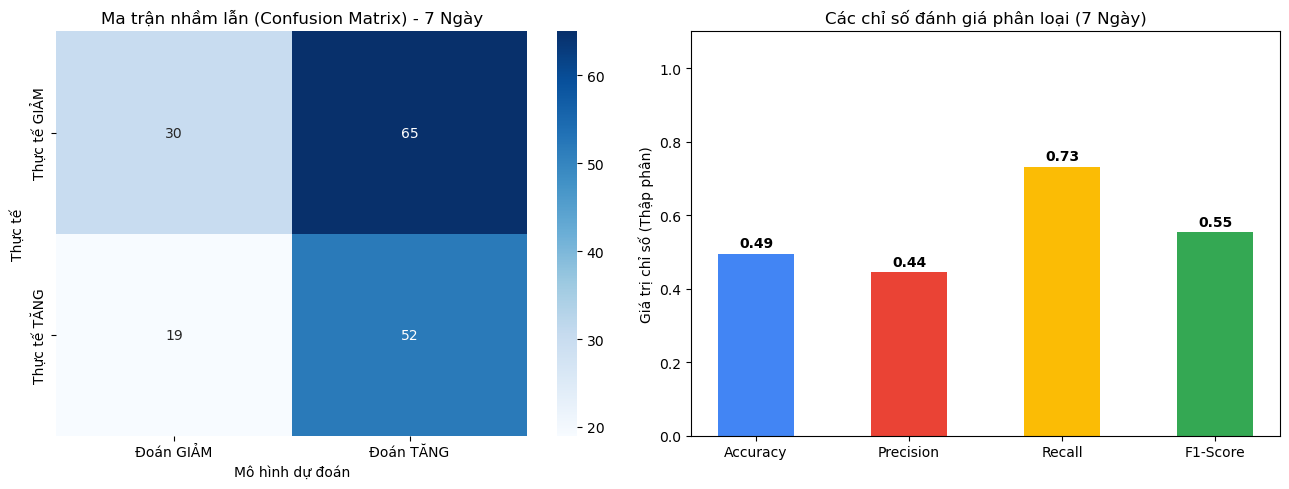

In [24]:
cm = confusion_matrix(actual_trend, predicted_trend)

plt.figure(figsize=(13, 5))

# Đồ thị 1: Confusion Matrix (Bên trái)
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Đoán GIẢM', 'Đoán TĂNG'], 
            yticklabels=['Thực tế GIẢM', 'Thực tế TĂNG'])
plt.title(f'Ma trận nhầm lẫn (Confusion Matrix) - {N_DAYS} Ngày')
plt.ylabel('Thực tế')
plt.xlabel('Mô hình dự đoán')

# Đồ thị 2: Biểu đồ cột các chỉ số dạng thập phân (Bên phải)
plt.subplot(1, 2, 2)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
# Giữ nguyên giá trị gốc (0, mấy), KHÔNG nhân với 100 nữa
metrics_values = [accuracy, precision, recall, f1]

bars = plt.bar(metrics_names, metrics_values, color=['#4285F4', '#EA4335', '#FBBC05', '#34A853'], width=0.5)
plt.ylim(0, 1.1)  # Đổi giới hạn trục Y từ 0 đến 1.1
plt.ylabel('Giá trị chỉ số (Thập phân)')
plt.title(f'Các chỉ số đánh giá phân loại ({N_DAYS} Ngày)')

# Hiển thị số thập phân (ví dụ: 0.58) trên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()